In [1]:
%pip install -r requirements-offline.txt --quiet

/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-32/.check-env-m7/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


# Module M7 — วิเคราะห์โมเดลที่เราสร้าง: Grad-CAM + metric รวมทุก modality

**Day 3, 10:30–11:30 · Offline (CPU)** — โมดูลนี้ "มองเข้าไปข้างใน" โมเดลที่เราเทรนเอง

เมื่อจบโมดูลนี้ ผู้เรียนจะ:
1. อธิบายได้ว่า **Grad-CAM** ทำงานอย่างไร — ใช้ gradient ของคะแนน class ย้อนกลับมาถึง feature map ของชั้น conv สุดท้าย เพื่อตอบว่า "โมเดลมองตรงไหน"
2. รัน **Grad-CAM ด้วย torch hooks ที่เขียนเอง** (ไม่ต้องติดตั้งไลบรารีเพิ่ม) บน CNN ที่เทรนไว้ใน M1
3. **รวม metric ทุก modality** — accuracy (ภาพ, M1) / CER (OCR, M2) / WER (เสียง, M5) — ลงตารางและภาพเดียว พร้อมรู้กับดักของการเทียบข้าม metric
4. ทำ **error inspection อย่างเป็นระบบ** — "โมเดลพลาดอะไร ทำไม" แบบที่ต่อยอดไปแก้ได้จริง

## โมเดล / ข้อมูล / เอกสารที่ใช้ (citation + license)

- **โมเดล CNN จาก M1** — สถาปัตยกรรม `SmallCNN`, subsample 10k/2k และ seed เดียวกับ `day1/module1_train_3_ways/` (สำเนาโค้ดตรงตัวอยู่ด้านล่าง) · โมดูลนี้โหลด checkpoint ถ้ามี (`data/m1_small_cnn.pt`) ถ้าไม่มีจะเทรนใหม่แบบเร็วเอง — ดูหมายเหตุใน §1
- **Fashion-MNIST** — Xiao, H., Rasul, K., & Vollgraf, R. (2017). *Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms*. arXiv:1708.07747 · <https://github.com/zalandoresearch/fashion-mnist> · **License: MIT**
- **Grad-CAM** — Selvaraju, R. R., et al. (2017). *Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization*. arXiv:1610.02391 (ตีพิมพ์ IJCV 2020) · <https://arxiv.org/abs/1610.02391> — โมดูลนี้ implement สูตรเองด้วย torch hooks ไม่พึ่งไลบรารีเสริม
- **PyTorch / torchvision** — <https://github.com/pytorch/pytorch>, **License: BSD-3-Clause** (หน้าที่ของ hooks: `Module.register_forward_hook` + `Tensor.register_hook`)
- ไลบรารีอื่น: scikit-learn (BSD-3-Clause), pandas/matplotlib (BSD)
- ค่า **CER ตัวอย่าง** ในตารางสรุป §4 มาจาก output ที่บันทึกไว้ของ `day1/module2_thai_ocr_bakeoff/book.ipynb` (dataset `openthaigpt/thai-ocr-evaluation`, **License: CC BY-SA 4.0**)

> **ขอบเขตการรัน:** Offline CPU ทั้งหมด — การรันครั้งแรกจะเทรน CNN ~1 นาที แล้วเซฟ checkpoint ลง `data/` (gitignored) รอบถัดไปโหลดทันที


## 0. เตรียมข้อมูลชุดเดียวกับ M1 (subsample 10k/2k, seed เดิม)

In [2]:
from pathlib import Path


def repo_root() -> Path:
    """หา repo root โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "requirements-offline.txt").exists():
            return p
    raise SystemExit(
        "ไม่พบ repo root — เปิด JupyterLab จาก repo root (uv run jupyter lab)"
    )


import os  # noqa: E402

# Fashion-MNIST: ใช้ datasets/fashion_mnist ที่ pre-bundle ไว้ก่อน
# (git LFS) — ถ้าไม่มีค่อยดาวน์โหลดลง data/ (gitignored) ตามเดิม
_fm = repo_root() / "datasets" / "fashion_mnist" / "FashionMNIST"
if _fm.exists():
    DATA = repo_root() / "datasets" / "fashion_mnist"
else:
    DATA = repo_root() / "data"

# weights ของ torchvision (MobileNetV3) — ใช้ datasets/models/torch
# ที่ pre-bundle ไว้ถ้ามี (torch.hub อ่าน TORCH_HOME ตอนโหลด weights)
_torch = repo_root() / "datasets" / "models" / "torch"
if _torch.exists():
    os.environ["TORCH_HOME"] = str(_torch)



In [3]:
import numpy as np  # noqa: E402
from torchvision.datasets import FashionMNIST  # noqa: E402

# download=True: โหลดจากดิสก์ทันทีบนเครื่อง offline ที่ pre-bundle ไว้แล้ว
train_full = FashionMNIST(root=DATA, train=True, download=True)
test_full = FashionMNIST(root=DATA, train=False, download=True)
print(train_full.data.shape, test_full.data.shape)


torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])


In [4]:
# fixed subsample 10k/2k — ชุดเดียวกับ M1 เป๊ะ (seed 42)
N_TRAIN, N_TEST = 10_000, 2_000
rng = np.random.default_rng(42)
idx_tr = rng.choice(len(train_full.data), N_TRAIN, replace=False)
idx_te = rng.choice(len(test_full.data), N_TEST, replace=False)
X_train = train_full.data.numpy()[idx_tr]
y_train = train_full.targets.numpy()[idx_tr]
X_test = test_full.data.numpy()[idx_te]
y_test = test_full.targets.numpy()[idx_te]
CLASS_EN = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]
print(X_train.shape, X_test.shape)


(10000, 28, 28) (2000, 28, 28)


## 1. โหลด CNN จาก M1 — checkpoint ถ้ามี / เทรนใหม่ถ้าไม่มี

โมเดลที่เราจะ "ส่องกล้อง" คือ CNN จากศูนย์ของ M1 (`SmallCNN` 2 ชั้น conv บน Fashion-MNIST) ปัญหาคือ notebook ของ M1 ยัง**ไม่บันทึก checkpoint ลงดิสก์** — โมเดลมันอยู่แค่ใน memory ของ kernel นั้น

ทางแก้ที่สะอาดที่สุดโดยไม่ต้องแก้ M1: เซลล์ถัดไปทำงานแบบ **โหลดถ้ามี / เทรนใหม่ถ้าไม่มี** —

- ถ้า `data/m1_small_cnn.pt` มีอยู่ (เพราะรันโมดูลนี้ไปแล้วรอบก่อน หรืออนาคต M1 ถูกปรับให้เซฟไฟล์ชื่อนี้) → โหลดทันที
- ถ้ายังไม่มี → เทรน**สำเนาสถาปัตยกรรม + ข้อมูล + seed เดียวกับ M1** 10 epochs (~1 นาที บน CPU) แล้วเซฟไว้ใช้รอบหน้า

รอบที่เทรนใหม่ได้โมเดล "เทียบเท่า" กับของ M1 (seed และ subsample เดียวกัน → accuracy ต่างกันไม่ได้) ตัวเลขจึงต่อเนื่องจากวันแรกได้จริง


In [5]:
import torch  # noqa: E402
import torch.nn as nn  # noqa: E402
from torch.utils.data import DataLoader, TensorDataset  # noqa: E402

Xtr_t = torch.from_numpy(X_train).float().unsqueeze(1) / 255.0
Xte_t = torch.from_numpy(X_test).float().unsqueeze(1) / 255.0
ytr_t = torch.from_numpy(y_train)
mean, std = Xtr_t.mean(), Xtr_t.std()
Xtr_n = (Xtr_t - mean) / std
Xte_n = (Xte_t - mean) / std
print(f"normalize: mean={mean:.4f} std={std:.4f}")


class SmallCNN(nn.Module):
    """CNN จิ๋ว 2 ชั้น conv — สถาปัตยกรรมเดียวกับ M1 (copy มาใช้)."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32 * 7 * 7, 10),
        )

    def forward(self, x):
        return self.net(x)


def train_cnn(X, y, epochs=10, bs=128, seed=0, log_every=0):
    """เทรน CNN ด้วย Adam คืนโมเดลที่เทรนแล้ว (โค้ดเดียวกับ M1)."""
    torch.manual_seed(seed)
    model = SmallCNN()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    g = torch.Generator().manual_seed(seed)
    dl = DataLoader(
        TensorDataset(X, y), batch_size=bs, shuffle=True, generator=g
    )
    for ep in range(epochs):
        model.train()
        for xb, yb in dl:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        if log_every and (ep + 1) % log_every == 0:
            print(f"  epoch {ep + 1}/{epochs}: loss={loss.item():.4f}")
    return model


def cnn_accuracy(model):
    model.eval()
    with torch.no_grad():
        pred = model(Xte_n).argmax(1).numpy()
    return accuracy_score(y_test, pred)


normalize: mean=0.2867 std=0.3535


In [6]:
from sklearn.metrics import accuracy_score  # noqa: E402

CKPT = DATA / "m1_small_cnn.pt"
cnn = SmallCNN()
if CKPT.exists():
    cnn.load_state_dict(
        torch.load(CKPT, map_location="cpu", weights_only=True)
    )
    print("โหลด checkpoint จาก:", CKPT)
else:
    print("ยังไม่มี checkpoint — เทรนใหม่ 10 epochs (~1 นาที บน CPU)")
    cnn = train_cnn(Xtr_n, ytr_t, epochs=10, log_every=2)
    torch.save(cnn.state_dict(), CKPT)
    print("เซฟ checkpoint ไว้ใช้รอบหน้าที่:", CKPT)

cnn.eval()
with torch.no_grad():
    preds = cnn(Xte_n).argmax(1).numpy()
acc_cnn = accuracy_score(y_test, preds)
print(f"CNN accuracy = {acc_cnn:.4f}  (M1 ได้ราว 0.86-0.88)")


โหลด checkpoint จาก: /Users/utarn/projects/ml-metrology/.claude/worktrees/issue-32/data/m1_small_cnn.pt
CNN accuracy = 0.8745  (M1 ได้ราว 0.86-0.88)


## 2. Grad-CAM — ถามโมเดลว่า "มองตรงไหน"

โมเดลจำแนกภาพได้ แต่เราไม่รู้ว่ามัน "ดู" ตรงไหน — ถ้าโมเดลจำแนกชิ้นงานชำรุดเพราะมอง**รอยประสานของรากฟันปลอมในภาพ** (มากกว่ารอยชำรุดจริง) accuracy สวยก็ยังใช้ไม่ได้

**Grad-CAM** (Selvaraju et al., 2017) ตอบด้วย gradient 3 ขั้น:

1. **หยอดภาพเข้าโมเดล** จับ feature map `A^k` ของทุกช่อง k ในชั้น conv สุดท้าย (ของโมเดลเรา: 32 ช่อง ขนาด 7×7)
2. **backward คะแนนของ class ที่สนใจ** `y^c` ย้อนมาที่ feature map แล้วเฉลี่ย gradient ทั้ง 7×7 ต่อช่อง: `α_k = (1/Z) Σ Σ ∂y^c/∂A^k` — ตัวเลขนี้คือ "ช่อง k สำคัญแค่ไหนต่อ class c"
3. **ผลรวมถ่วงน้ำหนัก + ReLU:** `L^c = ReLU(Σ_k α_k · A^k)` — heatmap 7×7 ที่ค่ามาก = บริเวณที่ดันคะแนนไปหา class นั้น (ReLU ตัดเฉพาะ "หลักฐานที่หนุน class" ทิศลบทิ้ง) แล้วขยายเป็น 28×28 ซ้อนบนภาพเดิม

ใน PyTorch เราไม่ต้องแตะ backward ด้วยมือเอง — ติด **hook** ที่ชั้น conv เป้าหมาย: `register_forward_hook` จับ activation ตอน forward แล้วติด tensor hook (`Tensor.register_hook`) ต่อท้าย activation นั้น เพื่อจับ gradient ที่ไหลผ่านตอน `.backward()`


In [7]:
import torch.nn.functional as F  # noqa: E402


class GradCAM:
    """Grad-CAM (Selvaraju et al., 2017) ด้วย torch hooks.

    forward hook จับ activation ของชั้น conv เป้าหมาย แล้วติด tensor
    hook ต่อเพื่อจับ gradient ของ feature map ตอน backward
    """

    def __init__(self, model, target_layer):
        self.model = model
        self.acts = None
        self.grads = None
        target_layer.register_forward_hook(self._save_act)

    def _save_act(self, module, inp, out):
        self.acts = out.detach()
        out.register_hook(self._save_grad)  # gradient ของ feature map

    def _save_grad(self, grad):
        self.grads = grad.detach()

    def cam(self, x, class_idx=None):
        """คืน (heatmap 28x28 ที่ normalize 0-1, class ที่คำนวณด้วย)."""
        self.model.eval()
        out = self.model(x)
        if class_idx is None:
            class_idx = int(out[0].argmax())
        self.model.zero_grad()
        out[0, class_idx].backward()
        w = self.grads[0].mean(dim=(1, 2))  # alpha_k — GAP ของ gradient
        cam = torch.relu((w[:, None, None] * self.acts[0]).sum(0))
        if cam.max() > 0:
            cam = cam / cam.max()
        cam28 = F.interpolate(
            cam[None, None], size=(28, 28), mode="bilinear",
            align_corners=False,
        )[0, 0]
        return cam28.numpy(), class_idx


ติด hook ที่ชั้น conv สุดท้าย (`cnn.net[3]` — `Conv2d(16, 32)` ซึ่ง output เป็น 32 ช่อง ขนาด 7×7) แล้วดู CAM ของภาพที่โมเดลทำถูก 5 ภาพแรก:

hook ที่ชั้น conv สุดท้าย (32 ช่อง, 7x7) พร้อมใช้แล้ว
ถูก 1749 / ผิด 251 จาก 2000 ภาพ


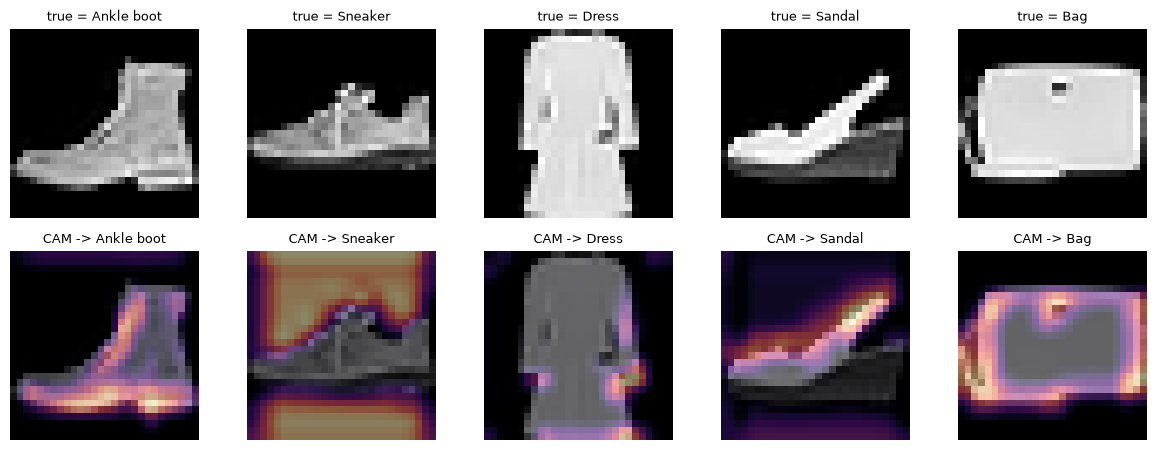

In [8]:
import matplotlib.pyplot as plt  # noqa: E402

cammer = GradCAM(cnn, cnn.net[3])  # Conv2d(16->32) — ชั้น conv สุดท้าย
print("hook ที่ชั้น conv สุดท้าย (32 ช่อง, 7x7) พร้อมใช้แล้ว")

ok_idx = np.where(preds == y_test)[0]
wrong_idx = np.where(preds != y_test)[0]
print(f"ถูก {len(ok_idx)} / ผิด {len(wrong_idx)} จาก {N_TEST} ภาพ")

fig, axes = plt.subplots(2, 5, figsize=(12, 4.6))
for col, i in enumerate(ok_idx[:5]):
    heat, p = cammer.cam(Xte_n[i:i + 1], class_idx=int(preds[i]))
    axes[0, col].imshow(X_test[i], cmap="gray")
    axes[0, col].set_title(f"true = {CLASS_EN[y_test[i]]}", fontsize=9)
    axes[1, col].imshow(X_test[i], cmap="gray")
    axes[1, col].imshow(heat, cmap="magma", alpha=0.55)
    axes[1, col].set_title(f"CAM -> {CLASS_EN[p]}", fontsize=9)
for ax in axes.ravel():
    ax.set_axis_off()
plt.tight_layout()
plt.show()


**อ่าน heatmap:** สีสว่าง (magma สูง) = บริเวณที่ดันคะแนนไปหา class นั้น สังเกตว่า CNN ไม่ได้อ่านทั้งภาพเท่ากัน — มักโฟกัสทรงร่างและส่วนสำคัญของวัตถุ (ตัวเสื้อ, พื้นรองเท้า, ลูกกระเป๋า)

**ข้อจำกัดที่ต้องจำ:** ชั้น conv สุดท้ายของโมเดลเราละเอียดแค่ **7×7** (MaxPool สองรอบจาก 28×28) — ตอนขยายกลับเป็น 28×28 จึงเบลอเป็นบล็อก นี่คือ trade-off ทั่วไปของ Grad-CAM: **ชั้นยิ่งลึกยิ่ง "เข้าใจโจทย์" แต่ยิ่งหยาบ** (ลองเทียบเองใน exercise ข้อ 1)


## 3. เมื่อโมเดลผิด — CAM ของภาพที่ทำนายพลาด

จุดที่ Grad-CAM คุ้มค่าที่สุดคือภาพที่โมเดล**ผิด** — เราจะเทียบ CAM สองแบบของภาพเดียวกัน: ของ class ที่โมเดลทำนาย (ผิด) กับของ class จริง

ทำนายผิด 251 / 2000 ภาพ


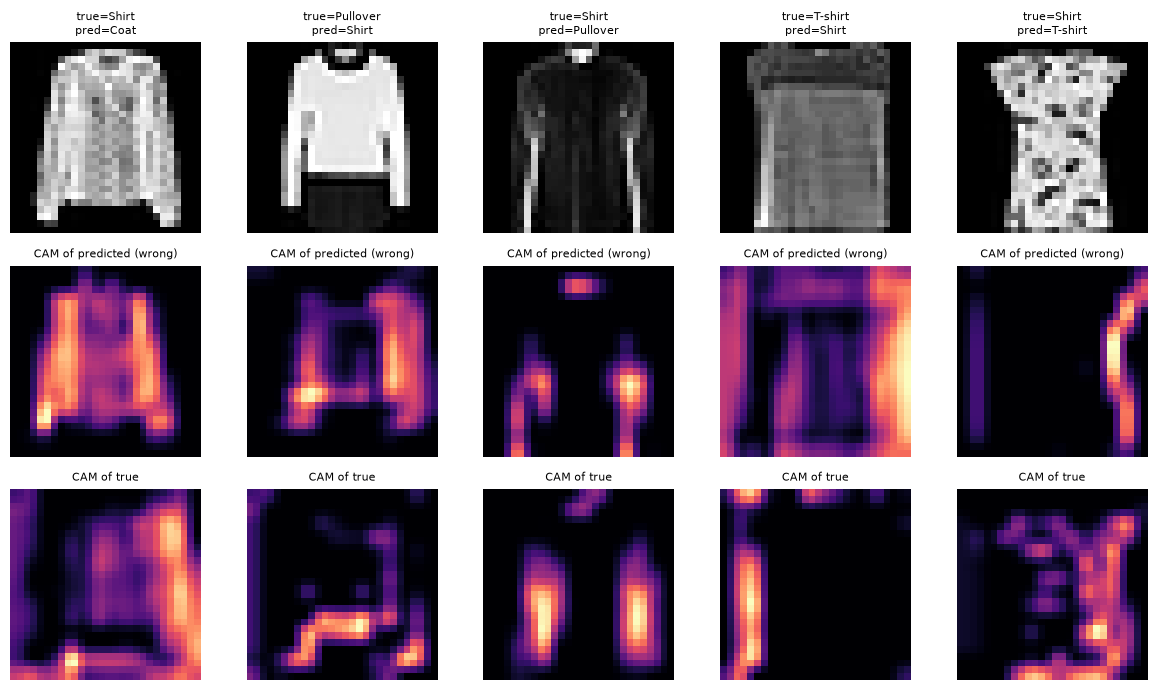

In [9]:
print(f"ทำนายผิด {len(wrong_idx)} / {N_TEST} ภาพ")

fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for col, i in enumerate(wrong_idx[:5]):
    x = Xte_n[i:i + 1]
    heat_p, p = cammer.cam(x, class_idx=int(preds[i]))
    heat_t, _ = cammer.cam(x, class_idx=int(y_test[i]))
    axes[0, col].imshow(X_test[i], cmap="gray")
    axes[0, col].set_title(
        f"true={CLASS_EN[y_test[i]]}\npred={CLASS_EN[p]}", fontsize=8
    )
    axes[1, col].imshow(heat_p, cmap="magma")
    axes[1, col].set_title("CAM of predicted (wrong)", fontsize=8)
    axes[2, col].imshow(heat_t, cmap="magma")
    axes[2, col].set_title("CAM of true", fontsize=8)
for ax in axes.ravel():
    ax.set_axis_off()
plt.tight_layout()
plt.show()


**อ่านสามแถวร่วมกัน:**

- ถ้า **CAM ของ pred และ CAM ของ true ทับกันมาก** → โมเดลมองบริเวณเดียวกันแต่ "ตีความ" ต่างกัน — รูปแบบคลาสสิกของคู่ที่หน้าตาคล้ายจริง (Shirt ↔ T-shirt/Pullover) โมเดลไม่ผิดเพราะมองผิดที่ แต่เพราะหลักฐานในภาพ 28×28 ขาวดำไม่พอแยก
- ถ้า **CAM ชี้คนละที่กัน** → โมเดลมองผิดจุดตั้งแต่ต้น — สัญญาณอันตรายกว่า (อาจเป็น shortcut เช่น มองพื้นหลัง/มุมภาพ)
- จำไว้: CAM บอก "โมเดลใช้หลักฐานจากตรงไหน" ไม่ใช่ "ทำไมถึงสรุปแบบนั้น" เชิงสาเหตุ — ใช้เป็นเครื่องมือ**ตั้งสมมติฐาน** แล้วตรวจด้วยข้อมูลจริงต่อ


## 4. รวม metric ทุก modality — accuracy / CER / WER

ตลอดคอร์สเราวัดโมเดลคนละ metric ตาม modality — ตอนนี้วางรวมกันบนโต๊ะเดียว:

| modality | โมดูล | metric | ทิศที่ดี | หน่วยของ "ความผิด" 1 หน่วย |
|---|---|---|---|---|
| ภาพ | M1 | **accuracy** | สูงยิ่งดี | ทั้งภาพหนึ่งใบจำแนกผิด |
| ข้อความ (OCR) | M2 | **CER** | ต่ำยิ่งดี | อักขระหนึ่งตัว (อ่านผิด/หล่น/แทรก) |
| เสียง (ASR) | M5 | **WER** | ต่ำยิ่งดี | คำหนึ่งคำถอดผิด |

**ประเด็นน่ารู้เรื่อง WER ภาษาไทย:** ภาษาไทยไม่เว้นวรรคระหว่างคำ — ในบทความ Whisper (Radford et al., 2022) การวัดบน FLEURS ภาษาที่ไม่เว้นวรรค (ไทยรวมอยู่) ทำโดยแทรกช่องว่างระหว่าง**ตัวอักษรทุกตัว** กล่าวคือ "WER" ที่รายงานจริง ๆ คืออะไรทำนอง CER — metric ข้าม modality จึง "ใกล้เคียงกันได้" แต่ไม่เหมือนกันเป๊ะ ต้องอ่านนิยามก่อนเสมอ

**ที่มาของค่าในตาราง:** accuracy คือค่าที่**รันสด**ใน notebook นี้ ส่วน CER คือค่าจาก output ที่บันทึกไว้ของ M2 ("จากการรันครั้งตัวอย่าง") และ WER เป็นค่า**ตัวอย่างเชิงประกอบ**ที่ผู้เรียนจะเติมด้วยผลจริงจาก M5 ของตัวเอง (ดูวิธีใน exercise ข้อ 4)


   modality module            model                                      metric  value                                     source
      image     M1 CNN from scratch                 accuracy (higher is better)  0.875                  live run in this notebook
      image     M1 CNN from scratch error rate = 1 - accuracy (lower is better)  0.125                  live run in this notebook
 text (OCR)     M2       thai-trocr                       CER (lower is better)  0.174                 example run recorded in M2
 text (OCR)     M2          EasyOCR                       CER (lower is better)  0.394                 example run recorded in M2
 text (OCR)     M2    Tesseract tha                       CER (lower is better)  0.894                 example run recorded in M2
audio (ASR)     M5   Whisper-medium                       WER (lower is better)  0.250 placeholder — fill in from your own M5 run


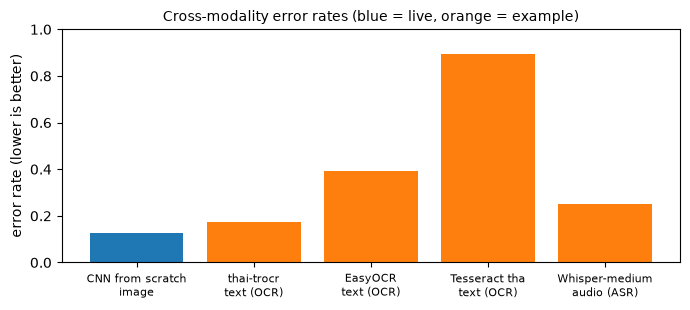

In [10]:
import pandas as pd  # noqa: E402

rows = [
    {"modality": "image", "module": "M1", "model": "CNN from scratch",
     "metric": "accuracy (higher is better)",
     "value": round(acc_cnn, 3),
     "source": "live run in this notebook"},
    {"modality": "image", "module": "M1", "model": "CNN from scratch",
     "metric": "error rate = 1 - accuracy (lower is better)",
     "value": round(1 - acc_cnn, 3),
     "source": "live run in this notebook"},
    {"modality": "text (OCR)", "module": "M2", "model": "thai-trocr",
     "metric": "CER (lower is better)", "value": 0.174,
     "source": "example run recorded in M2"},
    {"modality": "text (OCR)", "module": "M2", "model": "EasyOCR",
     "metric": "CER (lower is better)", "value": 0.394,
     "source": "example run recorded in M2"},
    {"modality": "text (OCR)", "module": "M2", "model": "Tesseract tha",
     "metric": "CER (lower is better)", "value": 0.894,
     "source": "example run recorded in M2"},
    {"modality": "audio (ASR)", "module": "M5", "model": "Whisper-medium",
     "metric": "WER (lower is better)", "value": 0.25,
     "source": "placeholder — fill in from your own M5 run"},
]
metric_table = pd.DataFrame(rows)
print(metric_table.to_string(index=False))

# ภาพเดียวรวมทุก modality — อัตราความผิดพลาด (ต่ำยิ่งดี) บนสเกล 0-1 เดียวกัน
plot_rows = metric_table[metric_table["metric"].str.contains(
    "lower is better"
)]
colors = ["tab:blue" if "live" in s else "tab:orange"
          for s in plot_rows["source"]]
labels = [f"{m}\n{mod}" for m, mod
          in zip(plot_rows["model"], plot_rows["modality"])]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(range(len(plot_rows)), plot_rows["value"], color=colors)
ax.set_xticks(range(len(plot_rows)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("error rate (lower is better)")
ax.set_ylim(0, 1)
ax.set_title("Cross-modality error rates (blue = live, orange = example)",
             fontsize=10)
plt.tight_layout()
plt.show()


**อ่านตาราง + กราฟร่วมกัน:**

- กราฟเดียวนี้เทียบได้เพราะเราแปลงทุก metric ให้เป็น "**อัตราความผิดพลาด**" บนสเกล 0–1 เดียวกัน (ภาพ: `1 − accuracy`, OCR: `CER`, เสียง: `WER`) — ต่ำยิ่งดีทุกแท่ง สีน้ำเงิน = รันสด, สีส้ม = ค่าตัวอย่าง
- **แต่ระวังกับดัก:** หน่วยความผิดไม่เท่ากัน — `1 − accuracy = 0.13` แปลว่า 13 ใน 100 ภาพจำแนกผิดทั้งใบ ส่วน `CER = 0.17` แปลว่า 17 ใน 100 อักขระผิด (คำเดียวที่ตัวเลขค่าการวัดผิด อาจเสียหายมากกว่าเสื้อผ้าจำแนกผิดหลายใบ) การเทียบข้าม modality จึงเทียบได้เชิง "ระดับความยากของโจทย์" เท่านั้น **ไม่ใช่ benchmark ตรง** — dataset คนละชุด โมเดลคนละตัว และ "ราคาของความผิด" ต่างกันทั้งหมด
- ในงานเมโทรโลยี คำถามที่ถูกคือ "**ความผิดแบบไหนแพงแค่ไหน**" — CER 0.1 บนตัวเลขค่าการวัด (ผิดหลักทศนิยม) อันตรายกว่า accuracy 0.9 บนงานคัดกรองภาพที่มีคนตรวจซ้ำ


## 5. Error inspection อย่างเป็นระบบ — "พลาดอะไร ทำไม"

วงจร 4 ขั้นที่ใช้ได้กับ**ทุก modality** (ภาพ/OCR/เสียง):

1. **รวบรวม error ทั้งหมด** — อย่าสุ่มดูแบบมองเห็นอะไรก็สะสม ให้ list ครบทุกภาพที่ผิด
2. **จัดกลุ่ม** — คู่สับสน (จริง i → ทำนาย j), ประเภทข้อมูลที่ผิดเยอะ (เอกสารสแกนเบลอ? เสียงมี noise?)
3. **มองตัวอย่างจริง** (และ CAM ถ้าเป็นภาพ) — ตัวเลขบอก "ผิดเท่าไร" แต่ตาคุณบอก "ผิดเพราะอะไร"
4. **ตั้งสมมติฐาน + แก้** — ข้อมูลไม่พอ? feature ไม่จับ? โมเดลเล็กไป? หรือคู่นี้แยกได้จริงแต่ต้องข้อมูลเพิ่ม

ขั้น 1–3 ทำด้วยโค้ดด้านล่าง:


In [11]:
from sklearn.metrics import confusion_matrix  # noqa: E402

cm = confusion_matrix(y_test, preds)
err_by_class = 1 - cm.diagonal() / cm.sum(1)
order = err_by_class.argsort()[::-1]
for i in order:
    n_err = int(cm[i].sum() - cm[i, i])
    print(f"{CLASS_EN[i]:<12} error {err_by_class[i]:.2%} ({n_err} ภาพ)")
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
r, c = np.unravel_index(cm_off.argmax(), cm_off.shape)
print(f"\nคู่สับสนสูงสุด: true={CLASS_EN[r]} -> pred={CLASS_EN[c]} "
      f"({int(cm_off[r, c])} ภาพ)")


Shirt        error 39.81% (82 ภาพ)
Pullover     error 21.31% (39 ภาพ)
T-shirt      error 20.51% (40 ภาพ)
Dress        error 12.75% (26 ภาพ)
Coat         error 10.55% (23 ภาพ)
Sneaker      error 6.19% (12 ภาพ)
Trouser      error 4.50% (9 ภาพ)
Sandal       error 3.83% (7 ภาพ)
Bag          error 3.32% (7 ภาพ)
Ankle boot   error 2.91% (6 ภาพ)

คู่สับสนสูงสุด: true=Shirt -> pred=Coat (28 ภาพ)


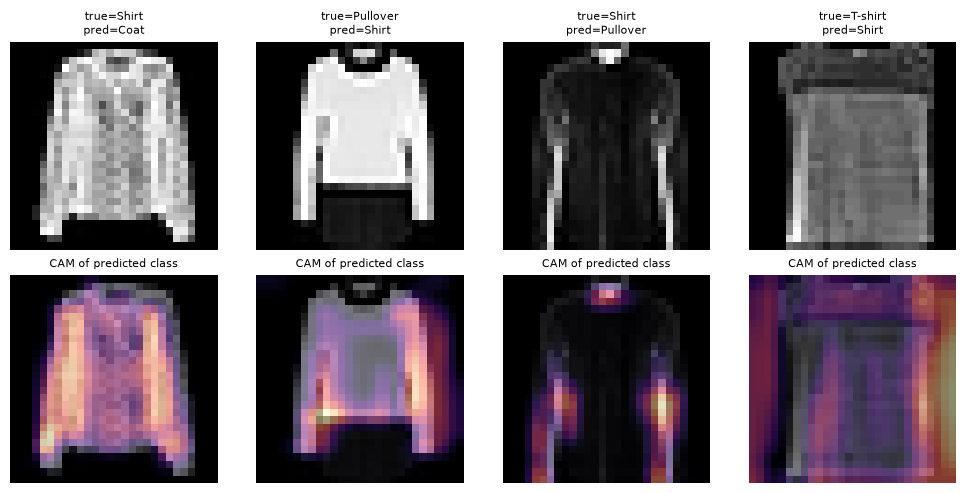

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for col, i in enumerate(wrong_idx[:4]):
    heat, p = cammer.cam(Xte_n[i:i + 1], class_idx=int(preds[i]))
    axes[0, col].imshow(X_test[i], cmap="gray")
    axes[0, col].set_title(
        f"true={CLASS_EN[y_test[i]]}\npred={CLASS_EN[p]}", fontsize=8
    )
    axes[1, col].imshow(X_test[i], cmap="gray")
    axes[1, col].imshow(heat, cmap="magma", alpha=0.55)
    axes[1, col].set_title("CAM of predicted class", fontsize=8)
for ax in axes.ravel():
    ax.set_axis_off()
plt.tight_layout()
plt.show()


**อ่านผล:**

- **per-class error:** โดยทั่วไป **Shirt** แย่สุดของ Fashion-MNIST (จากรอบตัวอย่างของเรา: error ~40%) — เพราะมัน "อยู่กลาง" ตระกูลเสื้อทั้งหมด (คล้าย T-shirt, Pullover, Coat พร้อมกัน) ส่วน Trouser/Bag/Ankle boot ง่ายสุดเพราะทรงไม่เหมือนใคร
- **คู่สับสนสูงสุด** (จากรอบตัวอย่างของเรา: true=Shirt → pred=Coat, 28 ภาพ) อยู่ในตระกูลเสื้อทั้งคู่ — สมเหตุสมผลเพราะทรงเสื้อ + ความยาวแขนคล้ายกันในภาพขาวดำ 28×28 แม้คนก็แยกยาก (รอบของคุณอาจให้คู่เพื่อนบ้าน เช่น T-shirt ↔ Shirt — ตอบจากผลจริง)
- เชื่อมกับ CAM ใน §3: ภาพที่ผิดเหล่านี้ CAM ของ pred/true ทับกันมาก — โมเดลมองถูกที่ แต่หลักฐานไม่พอ **นี่คือข้อจำกัดของข้อมูล ไม่ใช่ของโมเดล** — ทางแก้คือข้อมูล/ความละเอียดเพิ่ม ไม่ใช่เทรนนานขึ้น (เทียบกับบทเรียน learning curve ใน M1)


## 6. สรุป

| เครื่องมือในโมดูลนี้ | ตอบคำถาม | ข้อจำกัด |
|---|---|---|
| **Grad-CAM** | โมเดลมองตรงไหน | หยาบตามขนาด feature map (7×7); บอก "ที่ไหน" ไม่ใช่ "ทำไม" เชิงสาเหตุ |
| **ตาราง metric รวม** | ผิดเท่าไร หน่วยไหน | คนละ dataset/หน่วย — เทียบข้าม modality ได้เชิงสัญชาตญาณเท่านั้น |
| **Error inspection** | พลาดอะไร คู่ไหน ทำไม | ต้องมองตัวอย่างจริงด้วยตา ไม่ใช่อ่านตัวเลขอย่างเดียว |

**ข้อคิดสำหรับงานเมโทรโลยี:** โมเดลที่ "ถูกแต่อธิบายไม่ได้" ใช้ไม่ได้จริงในห้องแล็บ — ผลการวัดต้องตรวจสอบได้ (traceable) Grad-CAM ให้หลักฐานว่าโมเดลใช้บริเวณที่สมเหตุสมผลในภาพ (ไม่ได้อาศัยพื้นหลัง/สิ่งรบกวน) ควบคู่กับตาราง error ที่จัดกลุ่มแล้ว ทำให้ "เชื่อโมเดลอย่างมีเงื่อนไข" ได้: เชื่อ class ไหน ระวังคู่ไหน และต้องให้มนุษย์ตรวจซ้ำตรงไหน

**เชื่อมต่ออื่น ๆ:** heatmap ของ M6 (anomaly map จาก PatchCore) คือ "CAM อีกแบบ" ในเชิงภาพ — ทั้งคู่ตอบ "จุดไหนในภาพน่าสงสัย" ต่างกันที่ M6 ไม่ต้องมี label ชำรุดเลย และใน **Capstone** ทุก track ต้องส่ง "หลักฐานว่าโมเดลเชื่อได้" — เครื่องมือสามอย่างในโมดูลนี้คือแบบฟอร์มของหลักฐานนั้น
